/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.0739

📊 Test Accuracy (Iris): 1.0000


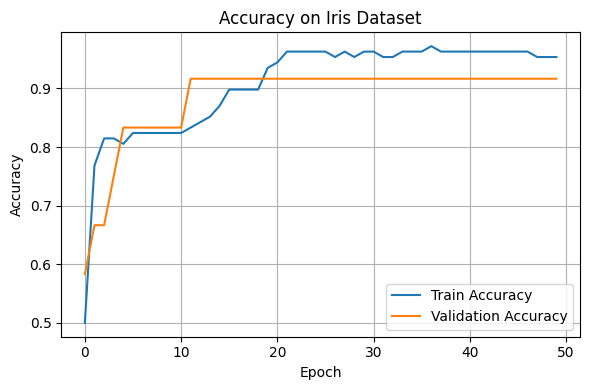

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 272kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.01MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.2MB/s]


Epoch 1/10 - Train Acc: 0.8179, Test Acc: 0.8416
Epoch 2/10 - Train Acc: 0.8617, Test Acc: 0.8539
Epoch 3/10 - Train Acc: 0.8748, Test Acc: 0.8689
Epoch 4/10 - Train Acc: 0.8826, Test Acc: 0.8692


In [ ]:
# ==============================
# Part 1: FCN for Iris data with TensorFlow
# ==============================
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Load Iris data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
data = pd.read_csv(url, names=columns)

# Preprocessing
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
le = LabelEncoder()
y = le.fit_transform(y)
y = tf.keras.utils.to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build FCN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(4,)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training
history_iris = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=0)

# Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n📊 Test Accuracy (Iris): {test_acc:.4f}")

# Accuracy plot
plt.figure(figsize=(6, 4))
plt.plot(history_iris.history['accuracy'], label='Train Accuracy')
plt.plot(history_iris.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy on Iris Dataset')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# Part 2: FCN for Fashion-MNIST with PyTorch
# ==============================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define FCN model
class FCN(nn.Module):
    def __init__(self):
        super(FCN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Train model
model = FCN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_acc_list = []
test_acc_list = []

for epoch in range(epochs):
    model.train()
    correct_train = total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = correct_train / total_train
    train_acc_list.append(train_acc)

    # Test
    model.eval()
    correct_test = total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)

    test_acc = correct_test / total_test
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

# Fashion-MNIST accuracy plot
plt.figure(figsize=(6, 4))
plt.plot(train_acc_list, label='Train Accuracy', color='blue')
plt.plot(test_acc_list, label='Test Accuracy', color='red')
plt.title('Accuracy on Fashion-MNIST (PyTorch)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
